# 01 — Exploratory Data Analysis

Goal: sanity-check the dataset before modeling. Class balance, missingness, univariate distributions split by class, correlations, and categorical default-rate breakdowns.

Headline questions:
1. How imbalanced is `default`?
2. Which numerics visually separate the two classes?
3. Are any features dangerously collinear (|r| > 0.8)?
4. Which categoricals carry signal?

In [1]:
import sys
from pathlib import Path
if '..' not in sys.path: sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_data

sns.set_theme(style='whitegrid', context='talk')
FIG_DIR = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = load_data()
print(df.shape)
df.head()

(50000, 15)


,loan_amount,term,int_rate,grade,emp_length,home_ownership,annual_income,purpose,dti,fico,open_acc,revol_util,noise_1,noise_2,default
0,10100.0,60,13.27,C,5,MORTGAGE,25200.0,debt_consolidation,16.10,711,14,52.7,0.808325,1.054941,0
1,7600.0,36,17.16,E,8,MORTGAGE,223000.0,debt_consolidation,19.04,664,11,36.2,-0.485312,-0.615192,0
2,14300.0,60,9.26,B,8,OWN,160800.0,credit_card,31.59,726,7,31.9,-0.913086,-1.034620,0
3,16400.0,60,8.41,B,2,OTHER,38000.0,credit_card,11.96,733,8,57.8,-0.621421,-0.684506,0
4,15400.0,36,29.86,G,5,MORTGAGE,144500.0,debt_consolidation,0.95,632,11,61.7,0.653340,2.221270,1


## Class balance

Imbalance dictates the metric (PR-AUC over accuracy) and motivates the cost-sensitive threshold in §8.

Default rate: 18.004%  (positives=9,002 / 50,000)


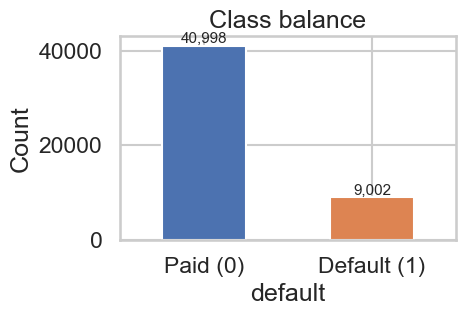

In [2]:
rate = df['default'].mean()
print(f'Default rate: {rate:.3%}  (positives={df["default"].sum():,} / {len(df):,})')

fig, ax = plt.subplots(figsize=(5, 3.5))
df['default'].value_counts().sort_index().plot(kind='bar', ax=ax, color=['#4c72b0', '#dd8452'])
ax.set_xticklabels(['Paid (0)', 'Default (1)'], rotation=0)
ax.set_ylabel('Count'); ax.set_title('Class balance')
for i, v in enumerate(df['default'].value_counts().sort_index()):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=11)
plt.tight_layout(); plt.savefig(FIG_DIR / 'class_balance.png', dpi=120); plt.show()

## Missingness

The synthetic generator emits no missing values. The check is here so the same notebook works on real Lending Club data.

In [3]:
miss = df.isna().mean().sort_values(ascending=False)
miss[miss > 0] if (miss > 0).any() else 'No missing values.'

'No missing values.'

## Numeric distributions by class

If a feature carries signal, the two class densities should sit in different places.

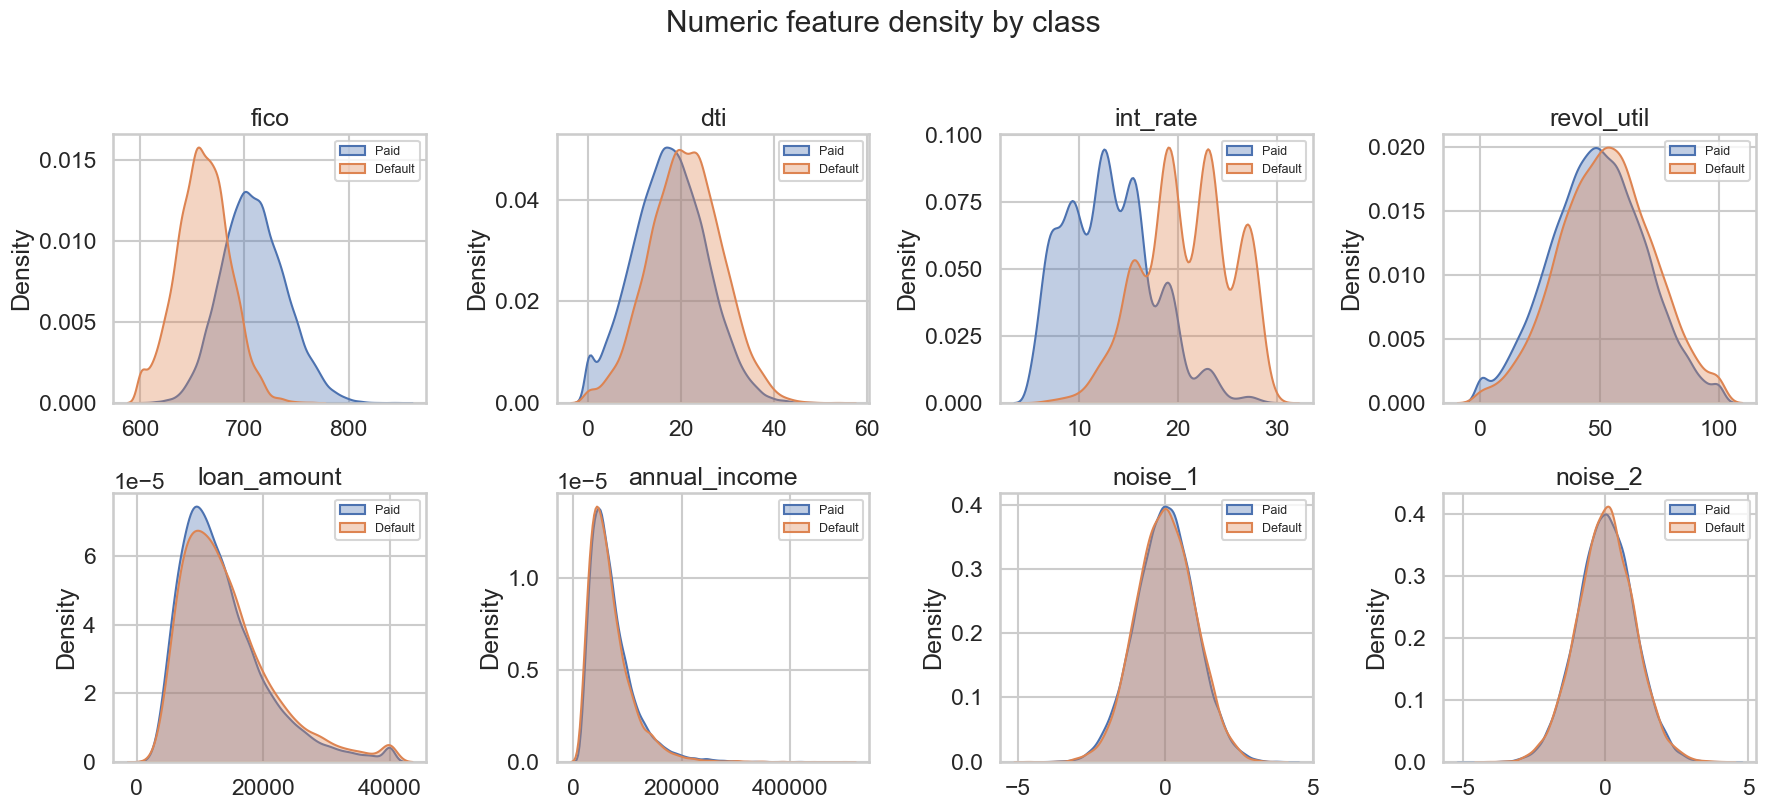

In [4]:
numeric_cols = ['fico', 'dti', 'int_rate', 'revol_util', 'loan_amount', 'annual_income', 'noise_1', 'noise_2']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, numeric_cols):
    for cls, color, label in [(0, '#4c72b0', 'Paid'), (1, '#dd8452', 'Default')]:
        sns.kdeplot(df.loc[df['default'] == cls, col], ax=ax, label=label, fill=True, alpha=0.35, color=color)
    ax.set_title(col); ax.set_xlabel(''); ax.legend(fontsize=9)
plt.suptitle('Numeric feature density by class', y=1.02)
plt.tight_layout(); plt.savefig(FIG_DIR / 'numeric_by_class.png', dpi=120, bbox_inches='tight'); plt.show()

FICO, DTI, and int_rate clearly separate the classes. revol_util and loan_amount shift modestly. annual_income shifts a little (lower-income borrowers default more — partly a pure income effect, partly the loan_to_income interaction baked into the DGP). The two `noise_*` distributions sit on top of each other — exactly what we want from pure noise.

## Correlation matrix on numerics

Anything with |r| > 0.8 is a flag for the linear model. Tree models tolerate it but interpretation gets muddier.

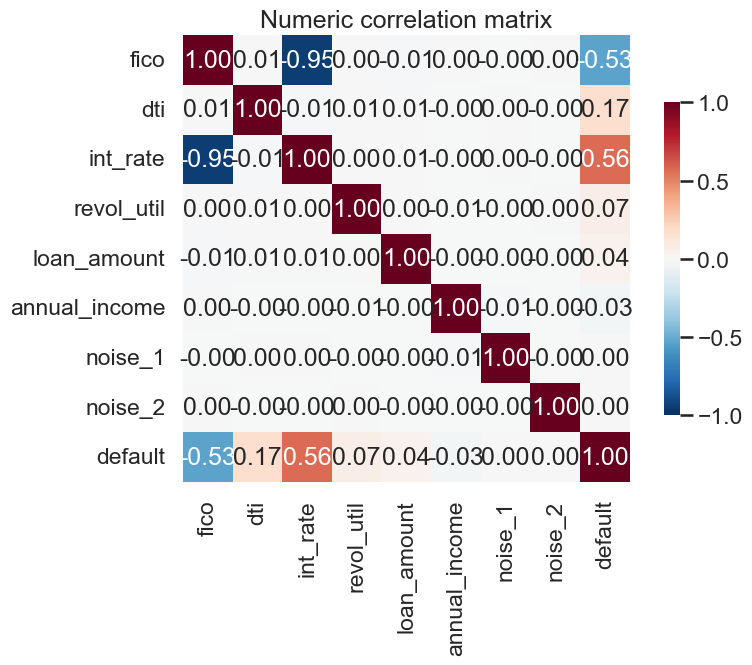

|r| > 0.8 pairs: [('fico', 'int_rate', -0.9479820716048197)]


In [5]:
num_df = df[numeric_cols + ['default']]
corr = num_df.corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Numeric correlation matrix')
plt.tight_layout(); plt.savefig(FIG_DIR / 'correlation_matrix.png', dpi=120); plt.show()

high = (corr.abs() > 0.8) & (corr.abs() < 1.0)
pairs = [(a, b, corr.loc[a, b]) for a, b in zip(*np.where(np.triu(high, k=1))) for a, b in [(corr.index[a], corr.columns[b])]]
print('|r| > 0.8 pairs:', pairs if pairs else 'none')

Talking point: I'd flag `int_rate` and the (one-hot encoded) `grade` as collinear, because grade is a FICO-bucket and rate is set from grade. We're keeping both for tree models. For a linear model I'd drop one.

## Categorical breakdowns: default rate by group

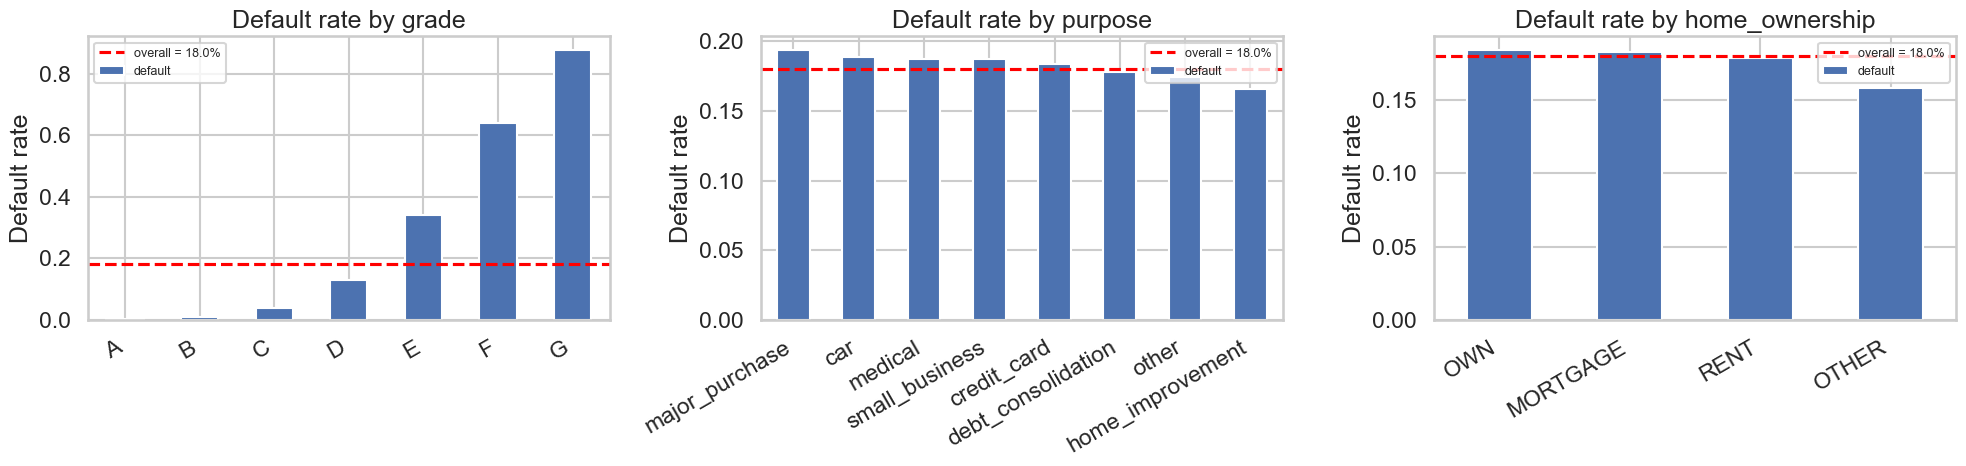

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, col, order in [
    (axes[0], 'grade', ['A','B','C','D','E','F','G']),
    (axes[1], 'purpose', None),
    (axes[2], 'home_ownership', None),
]:
    rates = df.groupby(col)['default'].mean().sort_values(ascending=False)
    if order is not None: rates = rates.reindex(order)
    rates.plot(kind='bar', ax=ax, color='#4c72b0')
    ax.axhline(df['default'].mean(), color='red', linestyle='--', label=f'overall = {df["default"].mean():.1%}')
    ax.set_title(f'Default rate by {col}'); ax.set_ylabel('Default rate'); ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right'); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(FIG_DIR / 'default_rate_by_category.png', dpi=120, bbox_inches='tight'); plt.show()

Grade is monotone (A=0.2% → G=88%) — exactly what we'd want from a credit grade and a strong sanity check on the data-generating process. Purpose and home_ownership carry only mild signal in this synthetic dataset; on real Lending Club, `small_business` typically defaults at roughly twice the overall rate.

## Takeaways into modeling

- Imbalance is moderate (~18% positives) — we'll report PR-AUC and tune a cost-sensitive threshold rather than relying on accuracy or a default 0.5 cutoff.
- FICO, DTI, int_rate are the most-separating numerics. The two noise features are visually inseparable; SHAP should rank them at the bottom (we'll verify in 03).
- int_rate ↔ grade collinearity is a real consideration. For trees, no action; for the logistic baseline, the one-hot of grade plus int_rate is fine because L2 regularization handles it, but it's worth flagging.
- No missingness in the synthetic file. The pipeline still includes a SimpleImputer so the same code runs on real LC data.